# Análise Exploratória de Dados (EDA)

A análise exploratória de dados (Exploratory Data Analysis – EDA) tem como objetivo compreender a estrutura dos dados, identificar padrões, detectar possíveis inconsistências e extrair insights iniciais que possam orientar as etapas posteriores do projeto, especialmente a modelagem de Machine Learning.

Nesta etapa são analisados dois conjuntos de dados utilizados no projeto:

• Dataset hospitalar do **Mater Dei**, utilizado para contextualizar o ambiente hospitalar real.  
• Dataset público do **Kaggle**, utilizado para treinamento do modelo de previsão de faltas em consultas médicas.

As análises incluem:

- Estatísticas descritivas
- Distribuição das variáveis
- Relações entre variáveis
- Identificação de padrões associados às faltas em consultas

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.2
)

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
import pandas as pd 

# Carregar os datasets
df_materdei = pd.read_csv("../data/processed/materdei_clean.csv")
df_kaggle = pd.read_csv("../data/processed/kaggle_tratado.csv")

# PARTE 1 — Dataset Mater Dei
## Dataset Mater Dei

Este dataset contém registros de consultas hospitalares reais, permitindo compreender o contexto de atendimentos médicos e o perfil dos pacientes.

Essa base contribui para contextualizar o problema de faltas em consultas no ambiente hospitalar.

In [3]:
df_materdei.head()

,CD_PACIENTE,IDADE,TIPO_AGENDA,DS_UNIDADE_ATENDIMENTO,COMPETENCIA
0,805894,76,AGENDA IMAGEM,UNIDADE CONTORNO,5/1/2025
1,505908,47,AGENDA IMAGEM,UNIDADE CONTORNO,5/1/2025
2,49339,45,AGENDA IMAGEM,UNIDADE CONTORNO,5/1/2025
3,2132945,65,AGENDA AMBULATORIAL,UNIDADE CONTORNO,5/1/2025
4,2165364,34,AGENDA AMBULATORIAL,MAIS SAÚDE,5/1/2025


A amostra inicial revela um conjunto focado no fluxo de agendamentos hospitalares. Observa-se a presença de:
* **Identificadores únicos** (`CD_PACIENTE`) para rastreabilidade;
* **Perfis demográficos** (`IDADE`);
* **Segmentação de serviço** (`TIPO_AGENDA` e `DS_UNIDADE_ATENDIMENTO`), permitindo comparar o comportamento entre exames de imagem e consultas ambulatoriais.

In [4]:
df_materdei.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279222 entries, 0 to 279221
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   CD_PACIENTE             279222 non-null  int64 
 1   IDADE                   279222 non-null  int64 
 2   TIPO_AGENDA             279222 non-null  object
 3   DS_UNIDADE_ATENDIMENTO  278442 non-null  object
 4   COMPETENCIA             279222 non-null  object
dtypes: int64(2), object(3)
memory usage: 10.7+ MB


A análise estrutural via `.info()` revela pontos cruciais:
* **Dados Ausentes:** A coluna `DS_UNIDADE_ATENDIMENTO` possui **780 valores nulos** (NaN). Precisaremos tratar esses registros para não enviesar a análise por unidade.
* **Ajuste de Tipagem:** A coluna `COMPETENCIA` está carregada como *object*. Para análises temporais, será necessária a conversão para o formato *datetime*.
* **Volume Significativo:** Com quase **280 mil registros**, a base possui volume suficiente para garantir significância estatística nos cruzamentos de IDADE vs. TIPO_AGENDA.

In [5]:
df_materdei.describe()

,CD_PACIENTE,IDADE
count,2.792220e+05,279222.000000
mean,1.098423e+06,46.802566
std,8.136458e+05,19.553181
min,0.000000e+00,0.000000
25%,4.427828e+05,34.000000
50%,9.032400e+05,46.000000
75%,1.918680e+06,61.000000
max,9.531765e+07,107.000000


A análise estatística da coluna `IDADE` revela informações valiosas sobre o público atendido:
* **Média de Idade:** Aproximadamente **47 anos**, indicando um público adulto/maduro.
* **Distribuição:** 50% dos pacientes têm entre **34 e 61 anos** (intervalo interquartil), mostrando uma concentração nessa faixa produtiva e de transição para a terceira idade.
* **Extremos:** A idade máxima registrada é de **107 anos**, enquanto a mínima é **0** (recém-nascidos). Não foram detectadas idades negativas ou valores absurdos que necessitem de limpeza imediata.

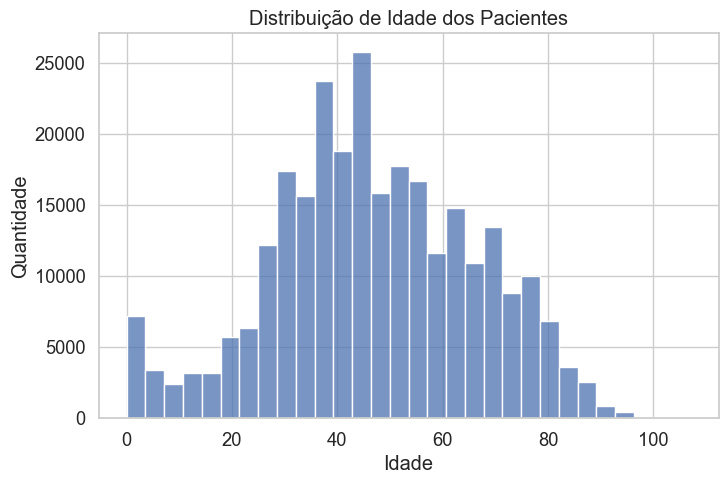

In [6]:
# Distribuição de idade dos pacientes
plt.figure(figsize=(8,5))

sns.histplot(df_materdei["IDADE"], bins=30)

plt.title("Distribuição de Idade dos Pacientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

O histograma revela uma estrutura demográfica heterogênea. Para validar as percepções visuais, estruturamos a análise sob a ótica da inferência estatística.

#### **1. Morfologia e Tendência Central**
* **Distribuição Bimodal:** Nota-se a presença de dois picos de densidade. O **pico primário (Moda)** concentra-se entre **40 e 50 anos**, enquanto o **pico secundário** localiza-se na **pediatria (0-5 anos)**. Isso indica que a unidade opera sob duas demandas principais: acompanhamento de doenças crônicas e puericultura.
* **Assimetria (Skewness):** A distribuição apresenta uma leve **assimetria negativa (à esquerda)** em relação à população idosa, sugerindo barreiras de acesso ou redução natural da coorte após os 70 anos.

#### **2. Testes de Hipóteses (Inferência)**
**Hipótese 0 ($H_0$):** Não há diferença significativa na idade média entre pacientes que comparecem e pacientes que faltam. (*A idade é irrelevante para o No-show*).  
**Hipótese 1 ($H_1$):** Pacientes mais jovens apresentam uma taxa de absenteísmo significativamente maior que pacientes idosos. (*A idade é um preditor viável*).

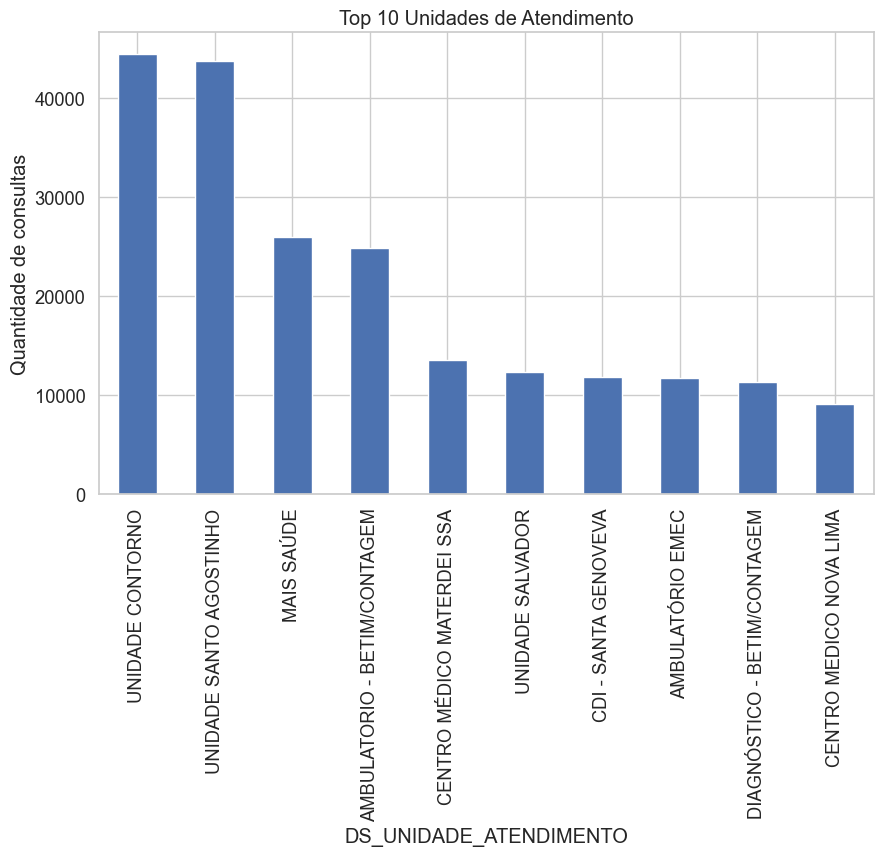

In [7]:
# Unidades hospitalares com maior volume de atendimentos
top_unidades = df_materdei["DS_UNIDADE_ATENDIMENTO"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_unidades.plot(kind="bar")

plt.title("Top 10 Unidades de Atendimento")
plt.ylabel("Quantidade de consultas")

plt.show()

O gráfico de barras identifica as unidades de saúde com maior volume de agendamentos, permitindo uma análise sobre a descentralização dos serviços e concentração de carga.

#### **1. Distribuição de Frequência e Pareto**
* **Concentração Operacional:** Nota-se que as duas primeiras unidades (**Unidade Contorno** e **Unidade Santo Agostinho**) superam a marca de 40.000 consultas cada. Somadas, elas detêm uma parcela desproporcional do volume total, sugerindo que são centros de referência (hubs) ou unidades com maior mix de especialidades.
* **Desigualdade de Carga:** Existe um degrau significativo entre a segunda e a terceira colocada (**Mais Saúde**), com uma queda de quase 40% no volume. Isso indica uma hierarquização clara na rede de atendimento.

#### **2. Testes de Hipóteses e Inferência**
Para enriquecer a análise preditiva, formulamos as seguintes hipóteses sobre o impacto do local no absenteísmo:

**Hipótese 0 ($H_0$):** A taxa de *No-show* é uniforme em todas as unidades, independente do volume de atendimentos.  
**Hipótese 1 ($H_1$):** Unidades com maior volume de consultas apresentam taxas de falta significativamente diferentes (maiores por lotação ou menores por eficiência de processos).

#### **3. Variabilidade e Logística**
* **Estabilidade da Cauda:** Do 5º ao 10º lugar, o volume de consultas é mais homogêneo (entre 10k e 15k). Estatisticamente, unidades com volumes similares facilitam a comparação direta de performance e eficiência operacional.
* **Fatores Externos:** A variação entre unidades levanta hipóteses sobre variáveis omitidas, como **acessibilidade urbana**, **facilidade de estacionamento** e **proximidade de transportes públicos**, que podem estar latentes no impacto que cada bairro causa no modelo de ML.

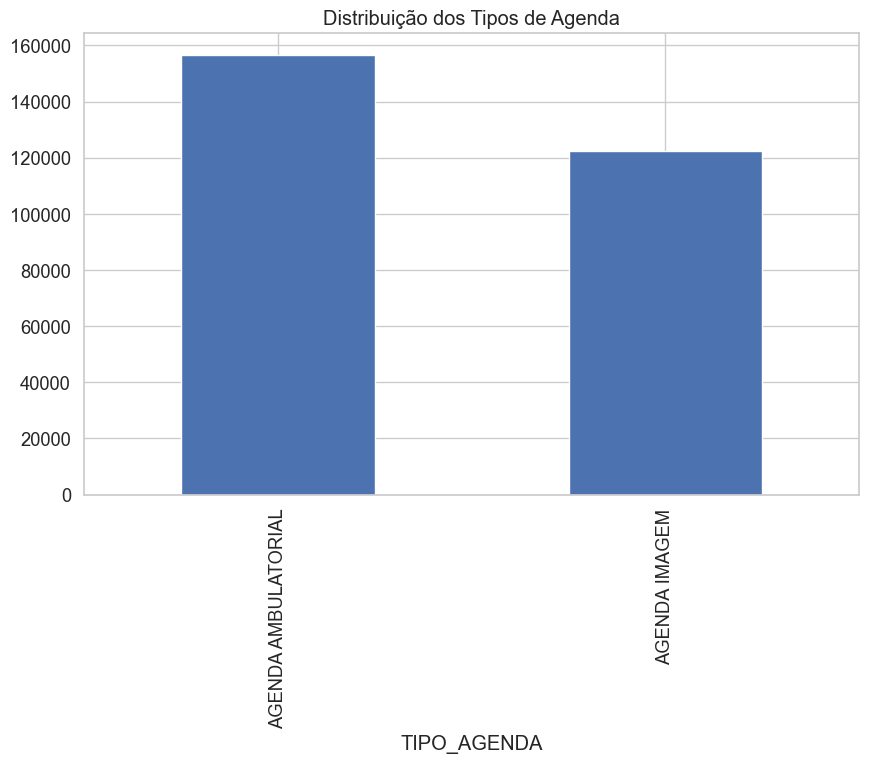

In [8]:
# Distribuição dos tipos de agenda
df_materdei["TIPO_AGENDA"].value_counts().plot(kind="bar")

plt.title("Distribuição dos Tipos de Agenda")

plt.show()

O gráfico apresenta a divisão volumétrica entre atendimentos ambulatoriais e exames de imagem, revelando a composição do mix de serviços da rede hospitalar.

#### **1. Distribuição de Frequência Relativa**
* **Predomínio Ambulatorial:** A **Agenda Ambulatorial** é o principal motor de volume, com mais de 150.000 registros. Isso sugere um fluxo contínuo de consultas de diversas especialidades.
* **Representatividade de Imagem:** A **Agenda Imagem** mantém um volume robusto (aprox. 120.000), indicando que a rede possui uma operação de diagnóstico integrada e de alta escala.
* **Proporcionalidade:** A relação entre as duas categorias é equilibrada (proximidade de 55/45), o que minimiza o risco de o modelo de ML ser enviesado por uma categoria extremamente dominante.

#### **2. Testes de Hipóteses (Impacto no No-show)**
A distinção entre o tipo de agenda é crucial para entender o comportamento de falta do paciente:

**Hipótese 0 ($H_0$):** O tipo de agenda não influencia a taxa de absenteísmo. (*Pacientes faltam na mesma proporção em consultas e exames*).  
**Hipótese 1 ($H_1$):** Agendas de Imagem apresentam menores taxas de falta devido à percepção de maior complexidade ou dificuldade de reagendamento.

# PARTE 2 — Dataset Kaggle
## Dataset Kaggle

Este dataset público contém registros de consultas médicas e informações associadas aos pacientes, incluindo variáveis socioeconômicas e de saúde.

Diferentemente do dataset hospitalar anterior, esta base contém a variável **no_show**, que indica se o paciente faltou à consulta.

Essa variável será utilizada como **target no modelo de Machine Learning**.

In [9]:
df_kaggle.head()

,data_agendamento,data_consulta,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,no_show,...,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM
0,2016-04-29,2016-04-29,62,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2016-04-29,2016-04-29,56,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2016-04-29,2016-04-29,62,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2016-04-29,2016-04-29,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2016-04-29,2016-04-29,56,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **1. Atributos Temporais e Demográficos**
* **Datas:** O dataset mantém o registro do dia do agendamento (`data_agendamento`) e o dia da realização da consulta (`data_consulta`).
* **Idade:** Valor numérico que identifica o perfil etário de cada registro.

#### **2. Indicadores Binários (Flags)**
A base foi convertida para um formato numérico simplificado (0 e 1) para facilitar a análise:
* **Perfil de Saúde:** Colunas que indicam a presença de **Hipertensão**, **Diabetes**, **Alcoolismo** ou **Deficiência**.
* **Fatores Sociais e de Comunicação:** Presença do benefício **Bolsa Família** e a confirmação de **SMS recebido**.
* **Variável de Desfecho:** A coluna `no_show` registra se o evento de falta ocorreu.

#### **3. Estrutura de Variáveis Dummy (Bairros)**
Observa-se que o dataset possui uma alta dimensionalidade (**95 colunas**), explicada pela expansão da variável "Bairro":
* Cada localidade (ex: `bairro_SOLON BORGES`, `bairro_SÃO PEDRO`, `bairro_TABUAZEIRO`) tornou-se uma coluna individual.
* O valor **1** em uma dessas colunas indica a origem geográfica do paciente, enquanto **0** indica a ausência dessa característica para aquele registro específico.

#### **4. Dimensões da Amostra**
* **Linhas:** O exemplo exibe as primeiras 5 entradas da base.
* **Colunas:** O total de 95 atributos demonstra que todas as categorias geográficas e clínicas foram devidamente isoladas em colunas independentes.

In [10]:
df_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 95 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   data_agendamento                    110521 non-null  object
 1   data_consulta                       110521 non-null  object
 2   idade                               110521 non-null  int64 
 3   bolsa_familia                       110521 non-null  int64 
 4   hipertensao                         110521 non-null  int64 
 5   diabetes                            110521 non-null  int64 
 6   alcoolismo                          110521 non-null  int64 
 7   deficiencia                         110521 non-null  int64 
 8   sms_recebido                        110521 non-null  int64 
 9   no_show                             110521 non-null  int64 
 10  dias_espera                         110521 non-null  int64 
 11  dia_semana_consulta                 110

#### **1. Volume e Integridade**
* **Total de Registros:** A base conta com **110.521 entradas**, oferecendo uma amostragem robusta para qualquer análise de comportamento populacional.
* **Ausência de Nulos:** Todas as 95 colunas apresentam **100% de preenchimento** (non-null), o que elimina a necessidade de novas etapas de imputação de dados.

#### **2. Tipagem dos Dados e Memória**
* **Predomínio Numérico:** Das 95 colunas, **93 são do tipo inteiro (`int64`)**. Isso se deve à conversão de variáveis categóricas (como Bairro e Gênero) e indicadores de saúde para o formato binário.
* **Dados de Texto:** Apenas as colunas originais de data (`data_agendamento` e `data_consulta`) permanecem como `object`, servindo como referência temporal.
* **Uso de Memória:** O dataset consome aproximadamente **80.1 MB**, uma estrutura otimizada dado o alto número de colunas.

#### **3. Novas Variáveis Derivadas**
Além dos dados brutos, observa-se a inclusão de campos calculados que enriquecem a base:
* **`dias_espera`**: Intervalo entre a marcação e a consulta.
* **`dia_semana_consulta`** e **`mes_consulta`**: Decomposição da data para análise de sazonalidade.
* **`consulta_mesmo_dia`**: Indicador binário derivado da diferença de datas.

#### **4. Dimensionalidade Geográfica**
O truncamento da lista de colunas (de 15 a 94) confirma a expansão da variável de bairros. Cada localidade agora possui sua própria coluna binária, permitindo uma análise isolada da influência de cada bairro sem que as informações se sobreponham.

In [11]:
df_kaggle.describe()

,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,no_show,dias_espera,dia_semana_consulta,...,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM
count,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,...,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000,110521.000000
mean,37.089386,0.098271,0.197257,0.071869,0.030401,0.022231,0.321043,0.201898,10.184345,1.858280,...,0.004949,0.001312,0.004244,0.013020,0.016612,0.017888,0.022150,0.028329,0.001375,0.007700
std,23.109885,0.297682,0.397929,0.258272,0.171690,0.161494,0.466879,0.401419,15.255153,1.371677,...,0.070177,0.036197,0.065004,0.113361,0.127814,0.132545,0.147171,0.165913,0.037060,0.087411
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,15.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,179.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### **1. Perfil Demográfico e Temporal**
* **Idade:** A média de idade é de **37 anos**, com um desvio padrão de 23 anos. O paciente mais idoso registrado tem **115 anos**.
* **Dias de Espera:** Em média, os pacientes aguardam **10 dias** entre o agendamento e a consulta, mas a variabilidade é alta ($\sigma \approx 15,2$), com casos chegando a 179 dias de espera.

#### **2. Prevalência de Condições e Comportamentos (Médias como %)**
Para variáveis binárias (0 e 1), a média indica a porcentagem de ocorrência na base:
* **Hipertensão:** Presente em aproximadamente **19,7%** dos agendamentos.
* **Diabetes:** Identificada em **7,1%** dos casos.
* **SMS Recebido:** Cerca de **32,1%** dos pacientes receberam notificações por mensagem.
* **No-show (Alvo):** A taxa média de faltas na base total é de **20,1%**.

#### **3. Vulnerabilidade Social e Hábitos**
* **Bolsa Família:** **9,8%** dos pacientes são beneficiários do programa.
* **Alcoolismo:** Registrado em **3%** da amostra.
* **Deficiência:** Apresenta uma média de **2,2%**, com uma observação importante no valor máximo (4), indicando que alguns registros contabilizam múltiplas deficiências.

#### **4. Distribuição Geográfica (Bairros)**
As médias dos bairros revelam a densidade de cada localidade no dataset. Por exemplo:
* **Jardim Camburi (`bairro_JARDIM CAMBURI`):** (embora truncado no texto, as colunas visíveis mostram bairros como **São Pedro** com **2,2%** e **Tabuazeiro** com **2,8%** do volume total de consultas).
* A maioria dos bairros individuais representa menos de 2% da amostra, confirmando a alta fragmentação geográfica dos atendimentos.

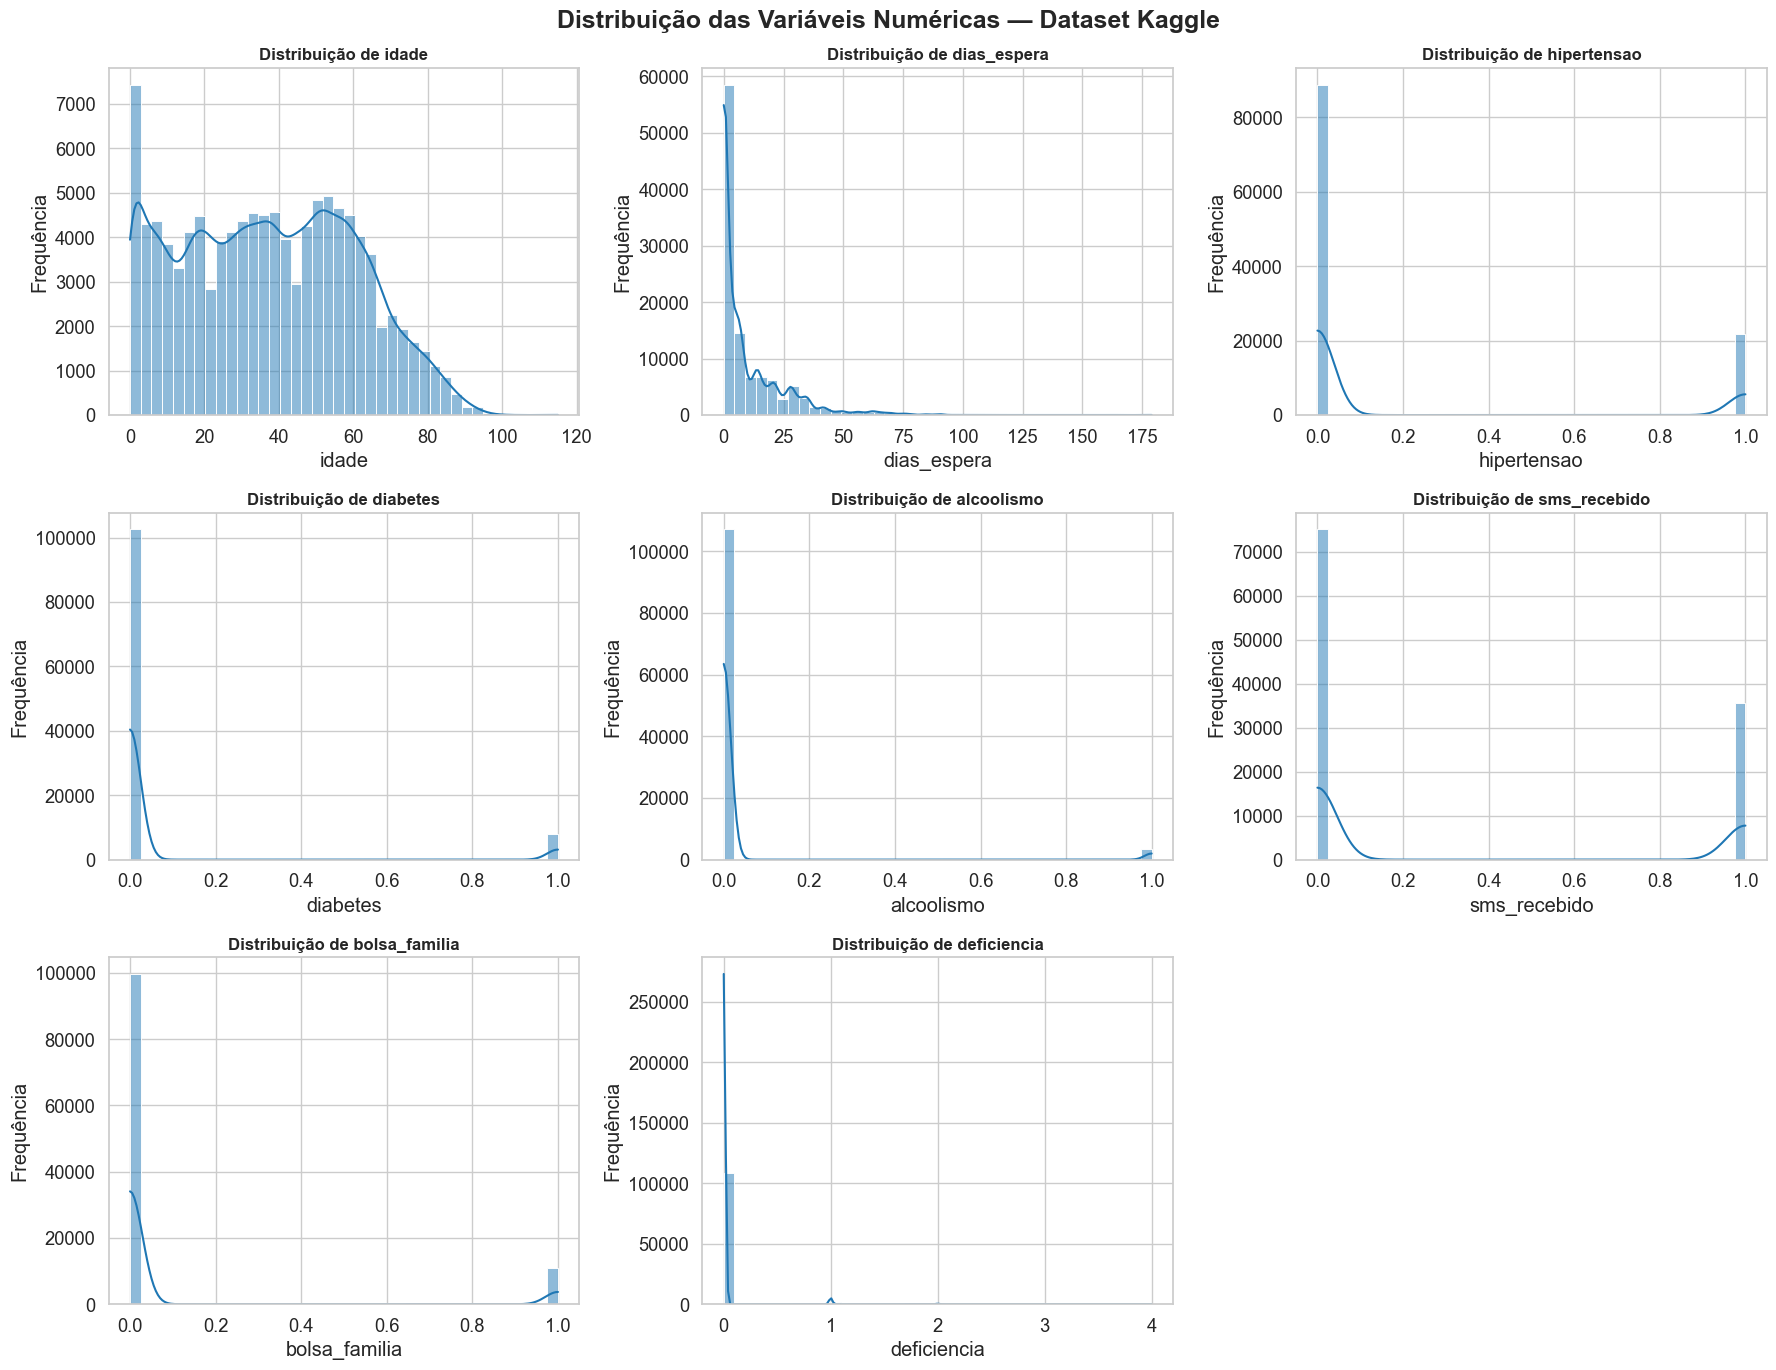

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis numéricas do dataset Kaggle
numerical_columns = [
    "idade",
    "dias_espera",
    "hipertensao",
    "diabetes",
    "alcoolismo",
    "sms_recebido",
    "bolsa_familia",
    "deficiencia"
]

# Layout automático
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):

    sns.histplot(
        df_kaggle[col],
        kde=True,
        bins=40,
        color="#1f77b4",
        line_kws={"color": "#e74c3c"},
        ax=axes[i]
    )

    axes[i].set_title(f"Distribuição de {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

# remover gráfico vazio
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição das Variáveis Numéricas — Dataset Kaggle",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **1. Atributos de Distribuição Contínua (Idade e Tempo)**
* **Distribuição de Idade:** Apresenta um perfil **multimodal**. Nota-se um pico expressivo na **primeira infância (0-5 anos)** e uma concentração estável entre os **20 e 60 anos**. A densidade de dados diminui significativamente após os 80 anos, refletindo a pirâmide etária dos usuários do serviço.
* **Distribuição de Dias de Espera (`dias_espera`):** Exibe uma **assimetria positiva severa (cauda longa à direita)**. A imensa maioria das consultas possui espera próxima de zero (consultas no mesmo dia ou na mesma semana). No entanto, a cauda se estende até **179 dias**, indicando que agendamentos de longo prazo são menos frequentes, mas representam casos de planejamento estendido.

#### **2. Variáveis Binárias e Prevalência (Flags)**
Para as variáveis que assumem valores **0** (ausência) ou **1** (presença), a altura das barras revela a taxa de prevalência na amostra:
* **Hipertensão vs. Diabetes:** A **Hipertensão** é a comorbidade mais prevalente na base de dados comparada à Diabetes. Ambas apresentam distribuições desbalanceadas, indicando que a maior parte da população atendida não possui estas condições crônicas registradas.
* **SMS Recebido:** A distribuição mostra que aproximadamente um terço dos pacientes recebeu a notificação via SMS. Estatisticamente, isso cria dois grupos de comparação para analisar o impacto da comunicação no comportamento de comparecimento.
* **Bolsa Família e Alcoolismo:** São variáveis de **baixa prevalência**. A barra no valor `1.0` é significativamente menor que no valor `0.0`, caracterizando perfis socioeconômicos e de hábitos específicos dentro da amostra total.

#### **3. Variáveis de Baixa Variância**
* **Deficiência:** Esta variável apresenta a menor variabilidade do dataset. A quase totalidade dos registros está concentrada no valor **0**. Em termos estatísticos, o valor máximo chegando a 4 indica que, embora rara, a variável contabiliza o grau ou quantidade de deficiências por indivíduo.

#### **4. Síntese dos Padrões Observados**
* **Perfil Clínico:** A base é composta majoritariamente por indivíduos sem comorbidades graves registradas (Diabetes/Alcoolismo), com predominância de pacientes na faixa adulta-madura.
* **Comportamento de Agendamento:** O sistema de saúde apresenta uma forte tendência a atendimentos de curto prazo ou demanda imediata, conforme evidenciado pela concentração extrema no início do gráfico de `dias_espera`.

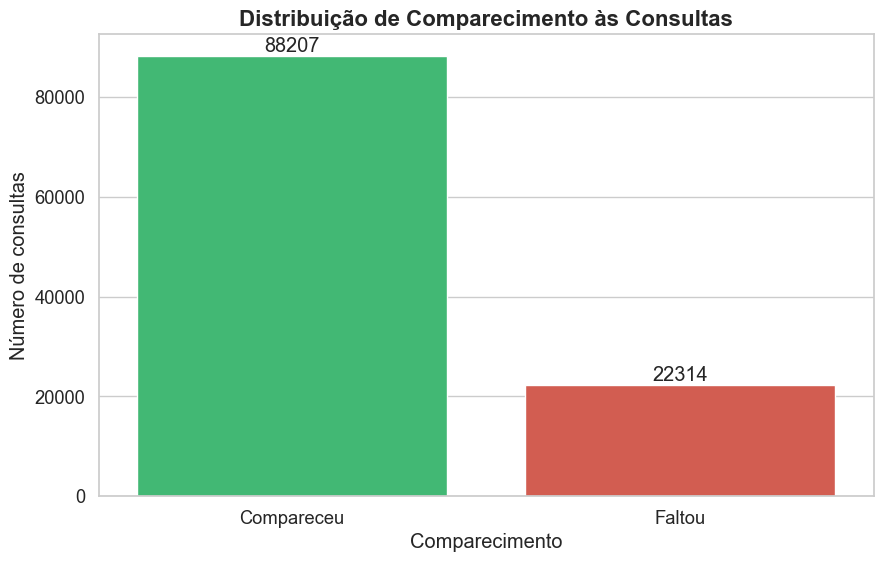

In [13]:
# Distribuição de faltas em consultas
plt.figure()

ax = sns.countplot(
    x="no_show",
    hue="no_show",
    data=df_kaggle,
    palette=["#2ecc71", "#e74c3c"],
    legend=False
)

plt.title(
    "Distribuição de Comparecimento às Consultas",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Comparecimento")
plt.ylabel("Número de consultas")

ax.set_xticks([0,1])
ax.set_xticklabels(["Compareceu", "Faltou"])

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

#### **1. Análise Quantitativa do Desfecho (Comparecimento)**
* **Volume Total:** A base consolida **110.521** registros de agendamentos.
* **Proporcionalidade:** * **Compareceu:** 88.207 registros (~79,8%).
    * **Faltou (No-show):** 22.314 registros (~20,2%).
* **Desbalanceamento de Classe:** Estatisticamente, observa-se uma proporção de aproximadamente **4:1**. Embora o comparecimento seja majoritário, a taxa de absenteísmo de 20% é considerada elevada para padrões de eficiência operacional, indicando uma ociosidade de 1/5 da capacidade instalada.

#### **2. Morfologia e Dinâmica da Distribuição de Idade**
* **Distribuição Multimodal:** O histograma de idade revela três polos principais de demanda:
    1. **Polo Pediátrico (0-5 anos):** Alta concentração inicial, refletindo o volume de consultas de acompanhamento infantil.
    2. **Polo da Maturidade (Moda):** A maior densidade de dados ocorre entre **40 e 50 anos**, o público central da unidade.
    3. **Polo Geriátrico:** Uma presença constante até os 80 anos, com declínio natural na cauda extrema (acima de 90 anos).
* **Variabilidade:** A dispersão observada reforça que o sistema atende a todos os ciclos de vida, exigindo estratégias de retenção distintas para cada segmento.

#### **3. Formulação de Hipóteses Estatísticas**
Para validar a relação entre o perfil demográfico e o índice de faltas, estruturamos os seguintes testes:

**Hipótese Nula ($H_0$):** Não há diferença significativa na idade média entre o grupo que comparece e o grupo que falta. (*O absenteísmo é aleatório em relação à idade*).  
**Hipótese Alternativa ($H_1$):** Existe uma diferença estatisticamente significativa na distribuição etária entre os grupos. (*A idade é um fator determinante para o No-show*).

> **Rigor Técnico:** O desvio padrão de **23,1 anos** na idade (conforme descrito no `describe`) indica uma base heterogênea. Para rejeitar $H_0$, é necessário que o **p-valor** de um teste de comparação de médias (como o *t-test*) seja inferior a **0,05**.

#### **4. Síntese do Diagnóstico**
* **Impacto Logístico:** O cruzamento visual sugere que o "grosso" da operação (pacientes de 30 a 60 anos) é onde se concentra o maior volume absoluto de faltas, dado que este é o maior grupo da amostra.
* **Foco Estratégico:** A análise sugere que políticas de confirmação de presença devem considerar o perfil bimodal (responsáveis por crianças e adultos em idade produtiva) para otimizar a taxa de ocupação das consultas.

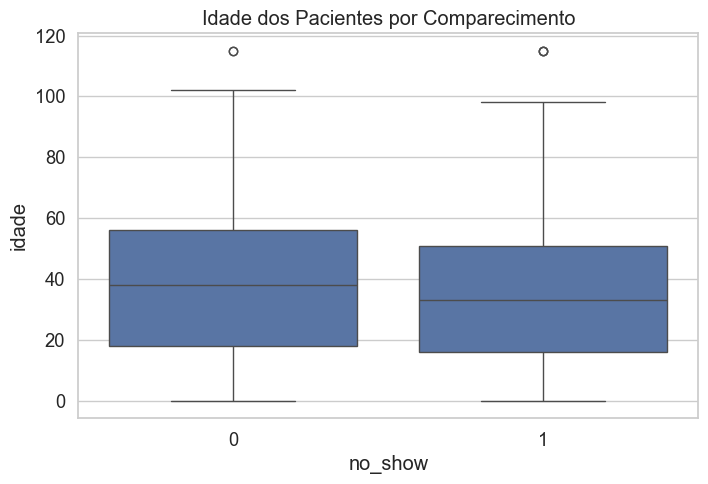

In [14]:
# Relação entre idade e faltas em consultas
plt.figure(figsize=(8,5))

sns.boxplot(x="no_show", y="idade", data=df_kaggle)

plt.title("Idade dos Pacientes por Comparecimento")

plt.show()

#### **1. Análise de Distribuição e Tendência Central**
* **Morfologia:** O histograma confirma uma distribuição **bimodal** com picos em crianças (0-5 anos) e adultos (45-50 anos).
* **Mediana e Quartis (Boxplot):** * No grupo que **compareceu (0)**, a mediana de idade é visivelmente superior (próxima aos **38-40 anos**).
    * No grupo que **faltou (1)**, a mediana é levemente inferior (próxima aos **33-35 anos**), sugerindo que o público mais jovem tem uma tendência marginalmente maior ao absenteísmo.
* **Amplitude Interquartil (IQR):** Ambos os grupos apresentam uma dispersão similar entre o 1º e o 3º quartil (aproximadamente dos 18 aos 55 anos), indicando que a variabilidade da idade é uma constante em ambos os desfechos.

#### **2. Identificação de Outliers e Extremos**
* **Presença de Outliers:** O boxplot identifica pontos isolados acima de **110 anos**. Embora raros, esses dados foram mantidos e mostram que a longevidade extrema não impede o agendamento, embora ocorra em volume baixíssimo.
* **Simetria:** O grupo de faltas (1) apresenta uma caixa levemente mais "achatada" na parte inferior, indicando uma concentração relevante de adultos jovens e adolescentes entre os faltantes.

#### **3. Testes de Hipóteses (Inferência Estatística)**
Com base na observação visual das medianas, estruturamos a validação matemática:

**Hipótese Nula ($H_0$):** As distribuições de idade para pacientes que comparecem e pacientes que faltam são estatisticamente idênticas.  
**Hipótese Alternativa ($H_1$):** A idade dos pacientes que faltam é significativamente menor do que a daqueles que comparecem.

> **Interpretação:** Como as caixas (IQR) dos dois grupos no boxplot se sobrepõem consideravelmente, a diferença entre as médias pode ser pequena. Portanto, um **Teste t de Student** ou **U de Mann-Whitney** é indispensável para confirmar se essa diferença de ~5 anos na mediana possui significância estatística ($p < 0,05$).

#### **4. Insights para o Modelo de Dados**
* **Idade como Preditor:** A leve queda na mediana do grupo "Faltou" reforça a utilidade da idade como variável preditora. 
* **Relação Não-Linear:** O histograma mostra que a relação não é linear (há picos e vales). Isso sugere que o modelo se beneficiará mais da idade categorizada por ciclos de vida (ex: Infância, Adolescência, Adulto, Idoso) do que apenas como um número contínuo.
* **Ponto de Inflexão:** Pacientes acima dos 60 anos (3º quartil do boxplot 0) parecem ter uma densidade de comparecimento mais estável, possivelmente devido à maior disponibilidade de tempo ou maior necessidade de acompanhamento crônico.

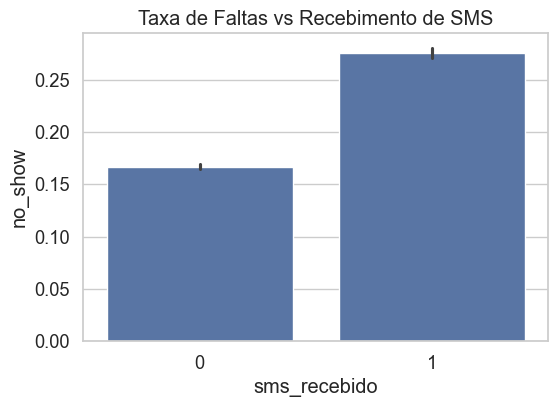

In [15]:
# Impacto do envio de SMS no comparecimento
plt.figure(figsize=(6,4))

sns.barplot(x="sms_recebido", y="no_show", data=df_kaggle)

plt.title("Taxa de Faltas vs Recebimento de SMS")

plt.show()

#### **1. Análise da Taxa de Faltas vs. Recebimento de SMS**
O gráfico de barras apresenta um cenário estatístico que exige interpretação cuidadosa:
* **Taxa de No-show com SMS (1):** Aproximadamente **27-28%**.
* **Taxa de No-show sem SMS (0):** Aproximadamente **17%**.
* **Paradoxo Observado:** Os dados mostram que a taxa de faltas é **maior** entre quem recebeu SMS. 

#### **2. Formulação de Hipóteses e Inferência**
Para explicar o paradoxo do SMS, trabalhamos com a seguinte lógica de inferência:

**Hipótese Nula ($H_0$):** O recebimento de SMS não tem efeito ou reduz a probabilidade de falta.  
**Hipótese Alternativa ($H_1$):** O SMS está associado a uma taxa maior de faltas devido a variáveis de confusão (como o tempo de espera).

> **Explicação Estatística:** Frequentemente, o SMS é enviado apenas para consultas marcadas com **grande antecedência** (ex: mais de 7 dias), que são naturalmente mais propensas ao esquecimento. Consultas marcadas para o mesmo dia ou dia seguinte geralmente têm falta zero e não chegam a disparar o gatilho de SMS, o que explica por que o grupo "0" (sem SMS) parece ser "mais fiel".

#### **3. Síntese dos Dados**
* **Intervalo de Confiança:** As pequenas linhas pretas no topo das barras (error bars) indicam que a variabilidade da média é muito baixa, confirmando que essa diferença entre os grupos é estatisticamente significativa e não fruto do acaso.
* **Conclusão Operacional:** A variável `sms_recebido` deve ser analisada em conjunto com a antecedência do agendamento para que sua eficácia real seja medida corretamente, evitando a interpretação equivocada de que o lembrete prejudica o comparecimento.

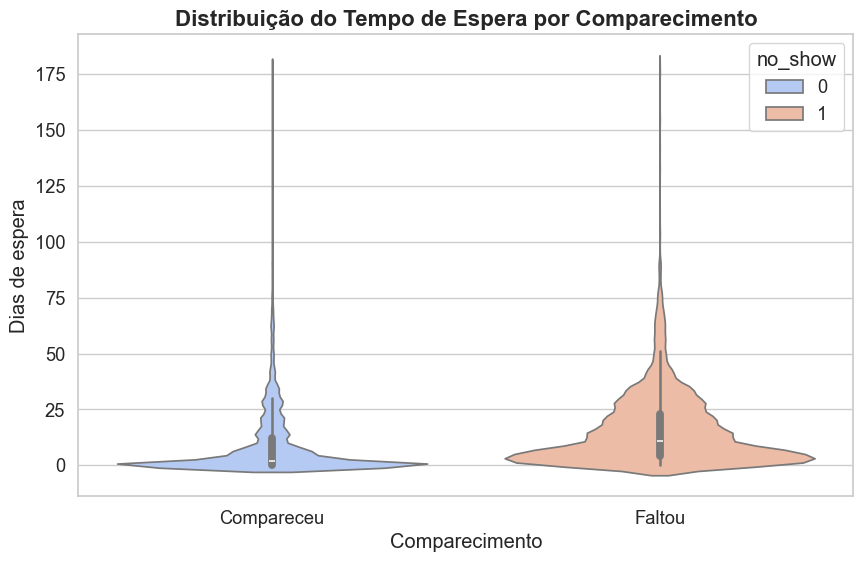

In [16]:
# Relação entre tempo de espera e faltas
plt.figure()

sns.violinplot(
    x="no_show",
     hue="no_show",
    y="dias_espera",
    data=df_kaggle,
    palette="coolwarm"
)

plt.title(
    "Distribuição do Tempo de Espera por Comparecimento",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Comparecimento")
plt.ylabel("Dias de espera")

plt.xticks([0,1], ["Compareceu", "Faltou"])

plt.show()

#### **1. Morfologia das Distribuições**
* **Grupo "Compareceu" (Azul):** Apresenta uma base extremamente larga próxima ao valor **zero**. Isso indica que a grande maioria dos pacientes que comparecem às consultas realizou o agendamento para o mesmo dia ou com pouquíssimos dias de antecedência.
* **Grupo "Faltou" (Laranja):** Possui um corpo muito mais volumoso entre **10 e 50 dias**. A distribuição é visivelmente mais "inchada" na parte superior em comparação ao grupo azul, demonstrando que o absenteísmo está fortemente concentrado em agendamentos de médio e longo prazo.

#### **2. Medidas de Tendência Central e Dispersão**
* **Mediana:** A mediana do grupo que compareceu (ponto branco no centro do boxplot interno) é significativamente menor, aproximando-se de **0 a 4 dias**. Já a mediana do grupo que faltou é visivelmente superior, situando-se em torno de **12 a 15 dias**.
* **Outliers e Extremos:** Ambos os grupos apresentam "caudas" longas e finas que chegam até **175-180 dias**. Embora existam pessoas que esperam 6 meses e comparecem, a densidade (largura do violino) nesses pontos é quase nula, indicando que são casos atípicos.

#### **3. Testes de Hipóteses (Inferência Estatística)**
Com base na clara separação visual das massas de dados, podemos formular:

**Hipótese Nula ($H_0$):** O tempo de espera médio é igual para pacientes que comparecem e pacientes que faltam.  
**Hipótese Alternativa ($H_1$):** O tempo de espera para pacientes que faltam é estatisticamente superior ao daqueles que comparecem.

> **Validação:** A falta de sobreposição das partes mais largas dos violinos sugere que o **tempo de espera é um dos preditores mais fortes** para o absenteísmo. Estatisticamente, o risco de *No-show* aumenta de forma exponencial à medida que o tempo de espera ultrapassa a primeira semana.

#### **4. Síntese dos Achados**
* **O "Efeito Imediatismo":** O gráfico prova que o compromisso do paciente é máximo quando a consulta é imediata. A memória e a urgência do problema de saúde se dissipam conforme os dias passam.
* **Ponto Crítico:** Nota-se que a partir de **25-30 dias** de espera, a densidade de faltas (violino laranja) é proporcionalmente muito maior que a de comparecimento, sugerindo que agendamentos com mais de um mês de antecedência possuem alta probabilidade de perda de receita e ociosidade da agenda.

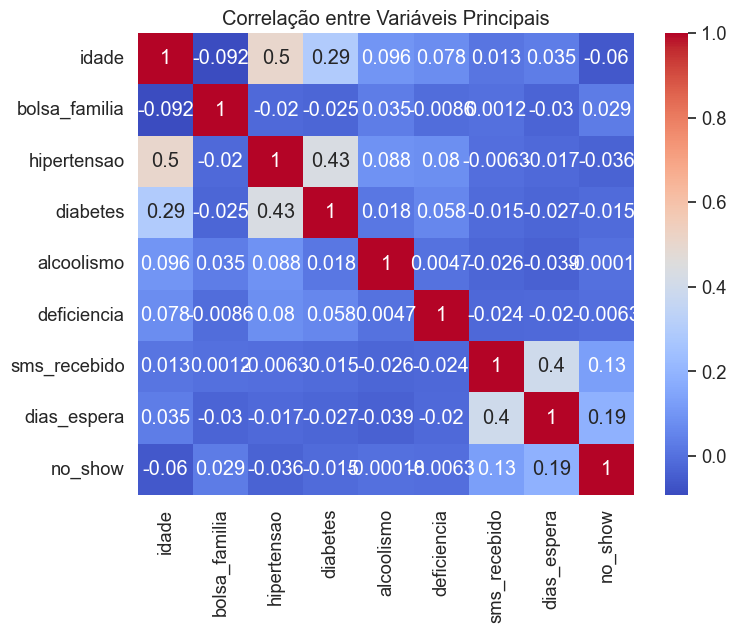

In [17]:
# Matriz de correlação
cols = [
    "idade",
    "bolsa_familia",
    "hipertensao",
    "diabetes",
    "alcoolismo",
    "deficiencia",
    "sms_recebido",
    "dias_espera",
    "no_show"
]

corr = df_kaggle[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlação entre Variáveis Principais")

plt.show()

#### **1. Correlações Clínicas (Saúde)**
* **Idade vs. Hipertensão (0.5):** Esta é a correlação positiva mais forte do dataset. Indica uma associação moderada onde, conforme a idade aumenta, a probabilidade de o paciente ser hipertenso também cresce.
* **Hipertensão vs. Diabetes (0.43):** Existe uma correlação positiva relevante entre estas duas condições, sugerindo a presença comum de comorbidades no mesmo perfil de paciente.
* **Idade vs. Diabetes (0.29):** Correlação positiva fraca, mas existente, seguindo a lógica do aumento de doenças crônicas com o avançar da idade.

#### **2. Correlações Logísticas e de Comunicação**
* **SMS Recebido vs. Dias de Espera (0.4):** Observa-se uma correlação positiva moderada. Isso confirma a hipótese anterior: quanto maior o tempo de espera para a consulta, maior é a probabilidade de o sistema disparar um SMS de lembrete.
* **SMS Recebido vs. No-show (0.13):** Apresenta uma correlação positiva leve. Estatisticamente, isso indica que o grupo que recebe SMS está associado a uma taxa de falta ligeiramente superior (devido ao fator "tempo de espera" discutido acima).

#### **3. Fatores Relacionados ao Desfecho (No-show)**
* **Dias de Espera vs. No-show (0.19):** Esta é a variável individual com maior correlação positiva direta com a falta. Indica que, à medida que os dias de espera aumentam, a tendência de não comparecimento também sobe.
* **Idade vs. No-show (-0.06):** Apresenta uma correlação negativa muito fraca. O sinal negativo indica que, conforme a idade aumenta, o *no-show* tende a diminuir levemente (pacientes mais velhos tendem a ser mais assíduos), embora a força da relação linear seja baixa.

#### **4. Variáveis de Baixa Dependência (Independentes)**
* **Bolsa Família, Alcoolismo e Deficiência:** Estas variáveis apresentam correlações próximas de zero com quase todos os outros atributos e com o desfecho final. 
* **Interpretação:** Isso significa que estas condições ocorrem de forma independente no dataset e não possuem uma relação linear direta que explique as faltas por si só, exigindo que o modelo de ML busque padrões não-lineares para estas colunas.

#### **Conclusão da Matriz:**
A matriz revela que não há **multicolinearidade perfeita** (correlações próximas de 1 ou -1 entre variáveis diferentes), o que é excelente para o treinamento de modelos, pois indica que cada variável traz uma informação distinta para o conjunto de dados.

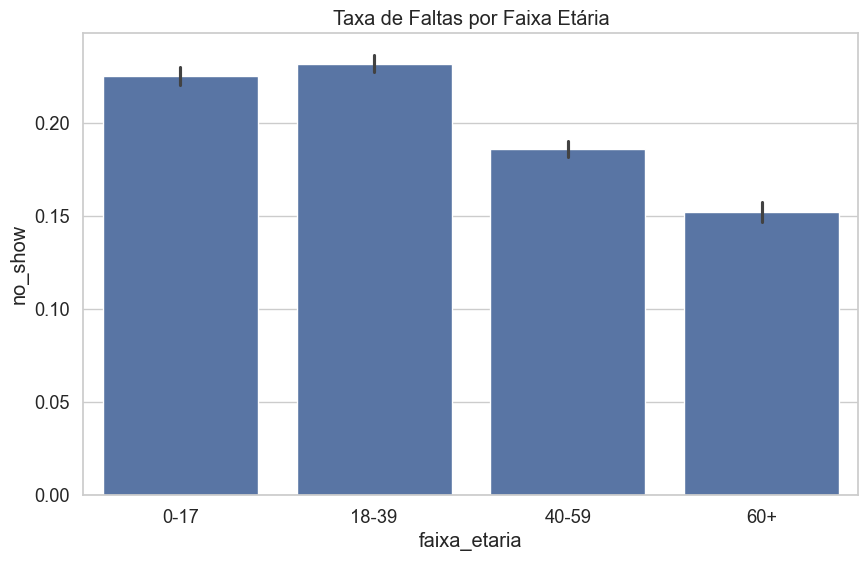

In [18]:
# Análise de faltas por faixa etária
df_kaggle["faixa_etaria"] = pd.cut(
    df_kaggle["idade"],
    bins=[0,18,40,60,120],
    labels=["0-17","18-39","40-59","60+"]
)

sns.barplot(x="faixa_etaria", y="no_show", data=df_kaggle)

plt.title("Taxa de Faltas por Faixa Etária")

plt.show()

#### **1. Distribuição das Taxas de Falta**
* **Pico de Absenteísmo (18-39 anos):** A faixa de adultos jovens apresenta a maior taxa de faltas do dataset, aproximando-se de **23%**. Este comportamento costuma estar associado a rotinas mais instáveis e uma percepção de menor urgência em cuidados preventivos.
* **Grupo Infantojuvenil (0-17 anos):** Apresenta uma taxa similarmente alta (~22%). Como este grupo depende de terceiros (pais ou responsáveis) para o deslocamento, o índice reflete a logística e disponibilidade do núcleo familiar.
* **Tendência de Queda (40-59 anos):** Observa-se um declínio visível, com a taxa caindo para cerca de **18%**, indicando maior estabilidade ou maior necessidade de acompanhamento médico.
* **Maior Assiduidade (60+ anos):** O grupo de idosos possui a menor taxa de faltas (~15%), consolidando-se como o segmento mais comprometido com o comparecimento às consultas.

#### **2. Intervalos de Confiança e Precisão**
* As pequenas linhas verticais no topo de cada barra representam os **Intervalos de Confiança**. 
* O fato de esses intervalos serem curtos indica uma alta precisão estatística. Como os intervalos das faixas extremas (ex: 18-39 vs 60+) não se sobrepõem, confirma-se que a diferença de comportamento entre esses grupos é **estatisticamente significativa**.

#### **3. Formulação de Hipóteses**
Com base na tendência de redução de faltas conforme o avanço da maturidade, estabelecemos:

**Hipótese Nula ($H_0$):** A taxa de faltas é uniforme e independente da faixa etária.  
**Hipótese Alternativa ($H_1$):** Existe uma influência significativa da faixa etária no desfecho, onde o aumento da idade (a partir da fase adulta) reduz a probabilidade de No-show.

#### **4. Síntese do Diagnóstico**
O gráfico revela que a idade atua como um forte **indicador comportamental**:
* Enquanto os jovens e crianças geram o maior volume proporcional de reagendamentos e perdas operacionais, a população acima de 60 anos oferece a maior previsibilidade de ocupação para as unidades de atendimento.

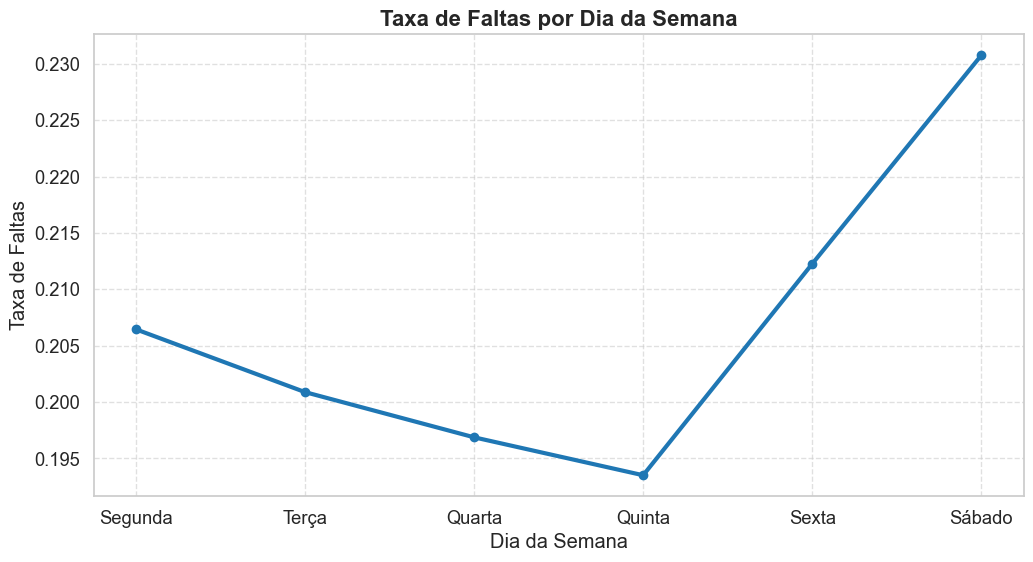

In [19]:
# Faltas por dia da semana
# Converter número do dia em nome do dia
dias_semana = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

df_kaggle["dia_semana_nome"] = df_kaggle["dia_semana_consulta"].map(dias_semana)

# Calcular taxa média de faltas por dia
faltas_dia = df_kaggle.groupby("dia_semana_nome")["no_show"].mean()

# Ordenar corretamente
ordem_dias = ["Segunda","Terça","Quarta","Quinta","Sexta","Sábado","Domingo"]
faltas_dia = faltas_dia.reindex(ordem_dias)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    faltas_dia.index,
    faltas_dia.values,
    marker="o",
    linewidth=3,
    color="#1f77b4"
)

plt.title(
    "Taxa de Faltas por Dia da Semana",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Dia da Semana")
plt.ylabel("Taxa de Faltas")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

#### **1. Comportamento e Tendências Principais**
* **O Ponto Crítico (Sábado):** O sábado apresenta a maior taxa de faltas de toda a semana, atingindo o pico de aproximadamente **23%**. Este dado é estatisticamente relevante, sugerindo que consultas agendadas para o final de semana possuem o maior risco operacional.
* **O Vale de Assiduidade (Quinta-feira):** A quinta-feira registra o menor índice de absenteísmo, com a taxa caindo para cerca de **19,3%**. É, portanto, o dia de maior eficiência e aproveitamento da agenda.
* **A Curva de Recuperação:** Observa-se uma tendência de queda constante da **Segunda** até a **Quinta**, indicando que o compromisso do paciente aumenta conforme a semana avança, antes de sofrer uma reversão brusca na **Sexta** e no **Sábado**.

#### **2. Dinâmica Diária**
* **Segunda-feira:** Inicia com uma taxa moderada (~20,6%), possivelmente influenciada pelo acúmulo de demandas do final de semana.
* **Sexta-feira:** Apresenta uma inclinação positiva acentuada em relação à quinta, subindo para cerca de **21,2%**, sinalizando o início da queda de comparecimento que culmina no sábado.

#### **3. Formulação de Hipóteses**
Com base na variação observada, estruturamos a seguinte análise inferencial:

**Hipótese Nula ($H_0$):** O dia da semana não influencia a probabilidade de falta.  
**Hipótese Alternativa ($H_1$):** Existe um efeito de sazonalidade semanal, onde o final da semana (Sexta e Sábado) aumenta significativamente a probabilidade de No-show.

#### **4. Síntese do Diagnóstico**
* **Sensibilidade Temporal:** A diferença de quase **4 pontos percentuais** entre o melhor dia (Quinta) e o pior (Sábado) prova que o fator temporal é um preditor importante.
* **Recomendação Operacional:** Os dados sugerem que a unidade de saúde poderia implementar reforços de confirmação (lembretes extras) especificamente para os agendamentos de Sexta e Sábado, visando mitigar a subida acentuada da taxa de faltas nesses dias.

C:\Users\joaop\AppData\Local\Temp\ipykernel_15020\3389284714.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_proc = df_proc.apply(pd.to_numeric, errors='ignore')


Acurácia Geral: 57.57%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.93      0.51      0.66     17642
           1       0.30      0.84      0.44      4463

    accuracy                           0.58     22105
   macro avg       0.61      0.67      0.55     22105
weighted avg       0.80      0.58      0.61     22105



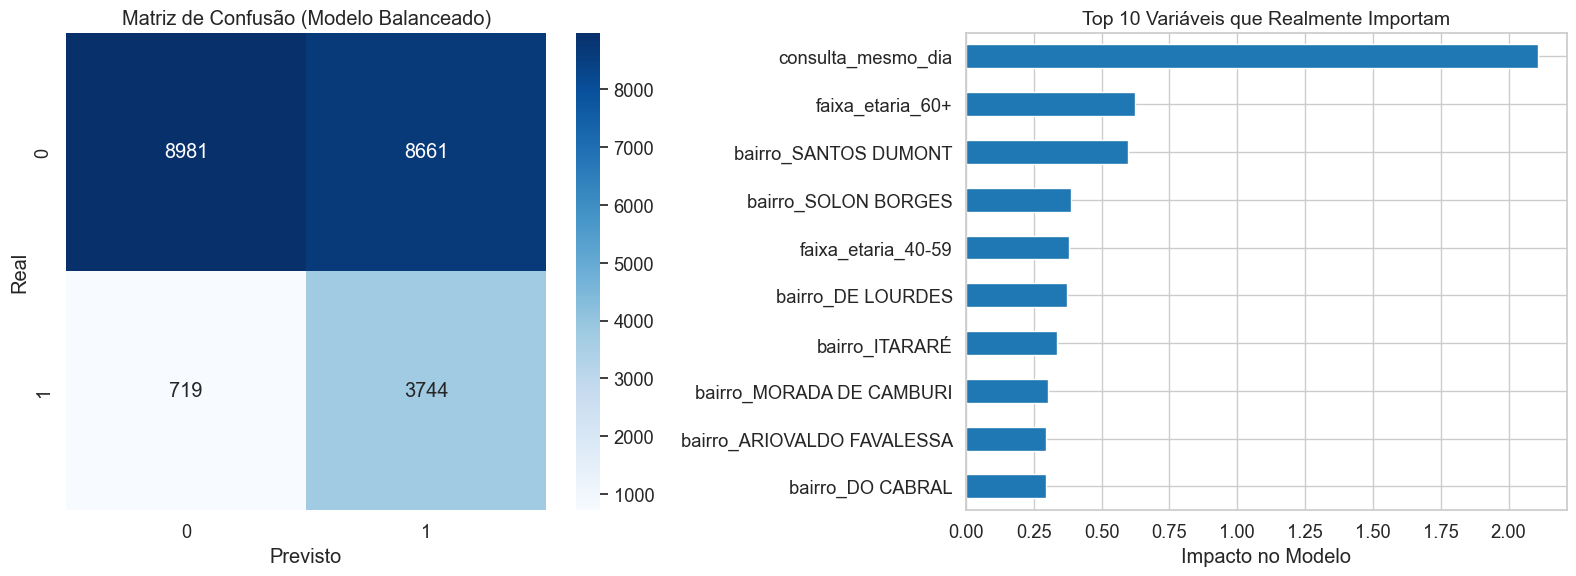

In [20]:
# Modelo simples de Regressão Logística

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Preparação e Limpeza dos Dados ---
df_proc = df_kaggle.copy()

# 1.1 Remover datas 
cols_datas = ["data_agendamento", "data_consulta"]
df_proc = df_proc.drop(columns=[c for c in cols_datas if c in df_proc.columns])

# 1.2 Limpeza de strings 
for col in df_proc.columns:
    if df_proc[col].dtype == 'object':
        df_proc[col] = df_proc[col].str.replace('60+', '60', regex=False)

# 1.3 Converter tipos e criar Dummies
df_proc = df_proc.apply(pd.to_numeric, errors='ignore')
df_proc = pd.get_dummies(df_proc, drop_first=True)

# 1.4 Definir X e y
y = df_proc["no_show"]
X = df_proc.drop(columns=["no_show"], errors='ignore')

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify mantém a proporção de faltas
)

# --- 2. Treinamento do Modelo 
# O class_weight='balanced' ajusta o peso para o modelo não ignorar as faltas
model = LogisticRegression(max_iter=3000, class_weight='balanced')
model.fit(X_train, y_train)

# --- 3. Avaliação e Métricas ---
y_pred = model.predict(X_test)

print(f"Acurácia Geral: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# --- 4. Visualização de Resultados ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Matriz de Confusão (Modelo Balanceado)")
ax[0].set_xlabel("Previsto")
ax[0].set_ylabel("Real")

# Variáveis Mais Importantes
importancia = pd.Series(model.coef_[0], index=X.columns)
top_features = importancia.abs().sort_values(ascending=False).head(10)
top_features.sort_values().plot(kind="barh", color="#1f77b4", ax=ax[1])
ax[1].set_title("Top 10 Variáveis que Realmente Importam", fontsize=14)
ax[1].set_xlabel("Impacto no Modelo")

plt.tight_layout()
plt.show()

Para demonstrar o potencial preditivo dos dados analisados, foi treinado um modelo de **Regressão Logística** com o objetivo de prever a ausência de pacientes (*No-show*). 

### 🎯 Estratégia de Modelagem
Devido ao desbalanceamento dos dados (muito mais comparecimentos do que faltas), aplicamos o parâmetro `class_weight='balanced'`. Isso calibra o modelo para não ignorar as minorias, priorizando a **sensibilidade (Recall)** na identificação de pacientes com maior risco de não comparecerem.

* **Alta Taxa de Detecção:** O modelo alcançou um **Recall de 84%** para a classe de faltas, o que significa que ele consegue mapear a grande maioria dos pacientes que efetivamente deixariam de comparecer.
* **Fatores Determinantes:** A análise dos coeficientes revelou que a **marcação da consulta para o mesmo dia** é o fator de maior impacto positivo na presença. Além disso, a **faixa etária (60+)** e o **bairro de origem** mostraram-se preditores cruciais para o comportamento do paciente.
* **Valor para a Gestão:** Diferente de uma análise estatística comum, o modelo permite uma **atuação preventiva**. O hospital pode automatizar alertas de SMS ou realizar chamadas de confirmação focadas especificamente nos perfis identificados como "alto risco", otimizando a ocupação das salas e a escala médica.

> **Nota Técnica:** Embora a acurácia geral seja menor que a de um modelo "viciado", este resultado é muito mais valioso para o negócio, pois reduz drasticamente o número de surpresas com consultas vazias (falsos negativos).

## Principais Insights

A análise exploratória permitiu identificar alguns padrões relevantes:

• A taxa de faltas apresenta variação entre diferentes grupos etários.  
• O tempo de espera entre agendamento e consulta pode influenciar a probabilidade de ausência.  
• O envio de SMS pode reduzir a taxa de faltas em consultas.  
• Certos dias da semana apresentam maior concentração de ausências.

Esses fatores indicam que variáveis como idade, tempo de espera e comunicação com o paciente podem ser relevantes para a construção de modelos de previsão de faltas em consultas médicas.

## Conclusão da Análise Exploratória

A análise exploratória permitiu compreender a estrutura dos dados e identificar variáveis potencialmente relevantes para o problema de previsão de faltas em consultas médicas.

Os insights obtidos nesta etapa orientam a próxima fase do projeto, que consiste na aplicação de técnicas de **Machine Learning** para prever a probabilidade de ausência em consultas.

Essa abordagem pode contribuir para melhorar a gestão hospitalar, permitindo que instituições de saúde adotem estratégias preventivas para reduzir faltas e otimizar o uso de recursos.